In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')




In [9]:
#tüm dosyaları birleştireceğiz.
files=['Apple.csv','Amazon.csv','Google.csv','Microsoft.csv','Netflix.csv']
all_data=[]

for file in files:
  temp_df=pd.read_csv(file)
  temp_df['Symbol']=file.split('.')[0] # dosya adından şirket adını alıyoruz
  all_data.append(temp_df)

df= pd.concat(all_data, ignore_index=True)

print("Temizlik öncesi")
print(f"Toplam satır:{len(df)}")
print(f"Eksik veri sayısı:\n{df.isnull().sum()}")
print("\nTekrar Eden Satır Sayısı:", df.duplicated().sum())

Temizlik öncesi
Toplam satır:27435
Eksik veri sayısı:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Date         0
Symbol       0
dtype: int64

Tekrar Eden Satır Sayısı: 0


In [12]:
df.dropna(inplace=True) #boş satırları siliyoruz ( şuan boş bir satırımız yok ama ilerde eklenecek herhangibir dosyayı da hesap etmen lazım)
df.drop_duplicates(inplace=True) # tekrar eden satırları siliyoruz
df.sort_values(by=['Symbol', 'Date'], inplace=True)# tarihe göre dizilim yaptık
print(df.head())

          Open      High       Low     Close  Adj Close     Volume  \
5839  4.075000  4.478125  3.952344  4.468750   4.468750  322352000   
5840  4.268750  4.575000  4.087500  4.096875   4.096875  349748000   
5841  3.525000  3.756250  3.400000  3.487500   3.487500  769148000   
5842  3.565625  3.634375  3.200000  3.278125   3.278125  375040000   
5843  3.350000  3.525000  3.309375  3.478125   3.478125  210108000   

            Date  Symbol  
5839  2000-01-03  Amazon  
5840  2000-01-04  Amazon  
5841  2000-01-05  Amazon  
5842  2000-01-06  Amazon  
5843  2000-01-07  Amazon  


In [16]:
df['Daily_Return']=df.groupby('Symbol')['Close'].transform(lambda x: x.pct_change()*100)

df['SMA50']= df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=50).mean())
df['SMA200']=df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=200).mean())

print("Finansal metrikler daily rutin sma50 sma200 hesaplandı")

Finansal metrikler daily rutin sma50 sma200 hesaplandı


In [17]:
votality=df.groupby('Symbol')['Daily_Return'].std()

print("Şirket bazlı risk analizi ( votalite)")
print(votality.sort_values(ascending=False))
print("\n Not: Voralite ne kadar yüksekse rişk o kadar fazladır")

Şirket bazlı risk analizi ( votalite)
Symbol
Netflix      3.587864
Amazon       3.185974
Apple        2.506215
Google       1.945160
Microsoft    1.943356
Name: Daily_Return, dtype: float64

 Not: Voralite ne kadar yüksekse rişk o kadar fazladır


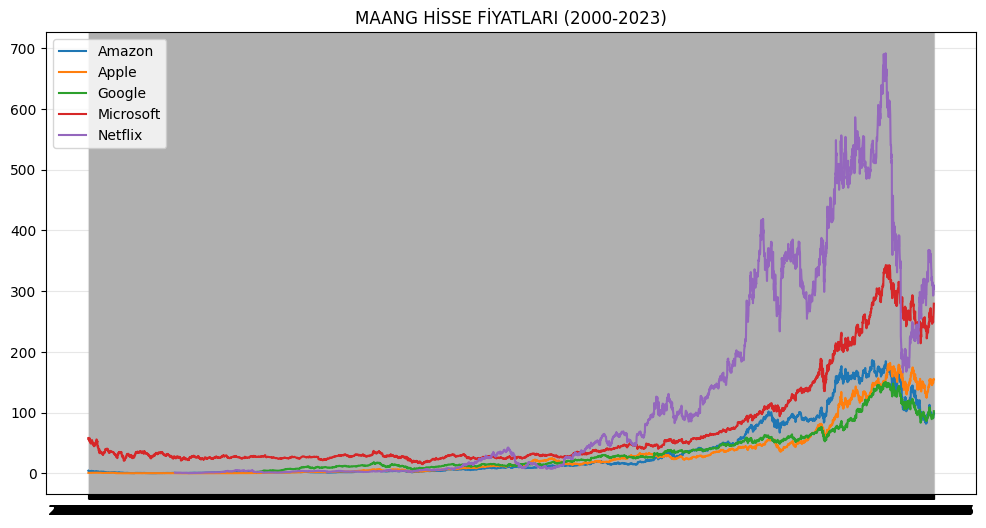

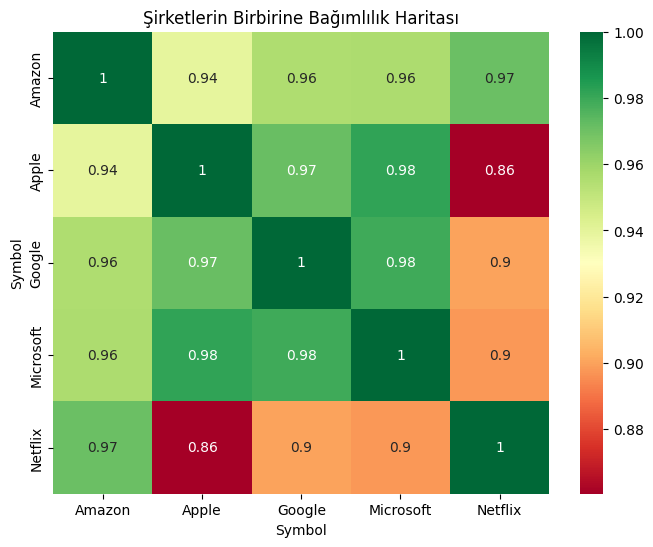

In [18]:
#fiyat karşılaştırma
plt.figure(figsize=(12,6))
for symbol in df['Symbol'].unique():
  subset = df[df['Symbol'] == symbol]
  plt.plot(subset['Date'], subset['Close'], label=symbol)

plt.title('MAANG HİSSE FİYATLARI (2000-2023)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#ısı haritası
pivot_df = df.pivot(index='Date', columns='Symbol', values='Close')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_df.corr(), annot=True, cmap='RdYlGn')
plt.title('Şirketlerin Birbirine Bağımlılık Haritası')
plt.show()